# Crisp method - Level-set + topological derivative

____
|**<u>Indicative duration</u>** : 1 hour
|---|

There are 4 types of code cells:
- **<font color='green'>[RUN & OBSERVE]</font>** $\rightarrow$ the cell should be run directly without modification
- **<font color='orange'>[RUN & PLAY]</font>** $\rightarrow$ the cell can be run directly, but some parameters should be changed interactively
- **<font color='red'>[FILL & RUN]</font>**    $\rightarrow$ the cell should be filled before being run
- **<font color='magenta'>[FILL & PLAY]</font>** $\rightarrow$ the cell should be filled, and then some parameters should be changed interactively.

___
## 1) Geometry

Consider the 2D domain $\Omega$ with a boundary $\partial \Omega$, containing a primary winding $P$ with back-and-forth conductors $P_+$ and $P_-$, as well as a secondary winding with back-and-forth conductors $S_+$ and $S_-$. 
The coils are fixed and the design zone is called $\Omega_c$.

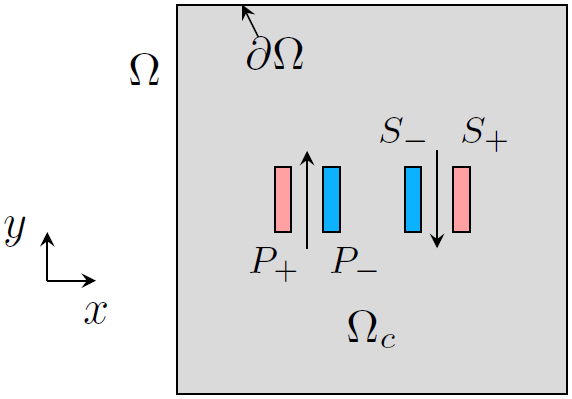

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 1 : Import transformer mesh
###############################################################################

from utils.geometry import transformer
from ngsolve.webgui import Draw

mesh = transformer(maxh = 1e-2)                   #  mesh the transformer geometry
print(f"Region names : {mesh.GetMaterials()}")   # display the regions (materials) labels
print(f"Line names : {mesh.GetBoundaries()}")    # display the lines (boundaries) labels
Draw(mesh)

_____
## 2) Magnetostatic problem


The magnetic state is the solution of the equation

$$
\text{find $a_\rho \in H^1_0(\Omega)$, such that }
$$
$$
\forall v \in H^1_0(\Omega), \quad  \mathcal R(a_\rho, v, \rho) = \int_\Omega \text{curl}\;v \cdot \nu\text{curl}\;a_\rho - \int_{P_+} v j + \int_{P_-} v j = 0,
$$

with $j = 10^6 A/m²$, and $\mathcal R(a, v)$ the residual. 

Look at [this notebook](1_FEM_forward_problem.ipynb) to see how to implement the abovementioned magnetostatic weak formulation, and this [cheat sheet](B_NGSolve_cheat_sheet.ipynb) for a reminder of NGSolve syntax.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 2 : Define magnetic reluctivity
###############################################################################

from numpy import pi
mu0 = 4e-7 * pi   # magnetic permeability of air (H/m)
mur = 1000        # relative magnetic permeability of the iron    
nu0 = 1/mu0
nuf = nu0/mur

In [ ]:
###############################################################################
## CODE CELL 3 : Define the magnetostatic solver
###############################################################################

j = 1e6 # current density in the primary coil (A/m²)

from ngsolve import CF, grad

def curl(v):
    R = CF(((0,1),(-1,0)), dims = (2,2))  # Rotation matrix of angle -pi/2
    return R * grad(v)

from ngsolve import H1, BilinearForm, LinearForm, dx
from utils.solver import solve

def state(nu):
    """ Solve the state equation for a given reluctivity field nu """
    fes = H1(mesh, order = 1, dirichlet = "dOmega")
    a, v = fes.TnT()    # define the trial and test functions 
    bf = BilinearForm(curl(v) * (nu * curl(a)) * dx)  
    lf = LinearForm(j * v * dx("Pp") - j * v * dx("Pm"))
    return solve(bf, lf)

#Try it
a,Kinv=state(nu0)
Draw(a)

____
## 3) Objective function & adjoint problem
### a) Objective function

We want to maximize the magnetic flux, which is
$$\phi(a) = L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a - \frac{1}{|S^-|}\int_{S^-} a \right)$$
with $N_s$ the number of turns of the secondary winding, and $L_z$ the length of the transformer in the $z$ direction (normalized to $L_z = 1m$ here). To comply with optimization customs and traditions, we define 
$$f(\rho) := -\phi(a_\rho)$$
the objective function to **<u>minimize</u>**.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 4 : Objective function
###############################################################################

from utils.solver import flux

# we want to maximize the secondary flux = minimize its opposite
def f(sol):
    return  -flux(sol)

print(f" {f(a) = :.5e} Wb/m")

### b) Adjoint problem

Since we want to compute some kind of derivative, we have to evaluate the adjoint state first.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 4 : Adjoint problem
###############################################################################

from ngsolve import dx

def df(a, rho, aStar):
    """ Directional derivative of the objective function in the direction aStar """
    return aStar*dx("Sm")  - aStar*dx("Sp")

from utils.optimization import solve_adjoint

p = solve_adjoint(a, nu0,  Kinv, df )
Draw(p)

____
## 4) Level set to cut ratio

We use a level-set function $\varphi$ to represent the geometry implicitely. In practice, the reluctivity $\nu$ depends on $\varphi$, such that

$$ 
\left\{
\begin{array}{lll}
\varphi > 0 &\rightarrow & \nu = \nu_0 = 1/\mu_0 & \text{air} \\
\varphi < 0 &\rightarrow & \nu = \nu_f = 1/(\mu_0\mu_r) & \text{iron} \\
\end{array}
\right.
$$

An advantage of the level-set representation is that is can represent sub-mesh geometries.
However, this is not the case of the physical solver... So the reluctivity in elements cut by the 0 level-set will be filled by a weighted average of reluctivities of air and iron.
To use boddy-fitted mesh, have a look at [mmg tools](https://www.mmgtools.org/).

|**<font color='green'>[RUN & OBSEVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 5 : Level set representation
###############################################################################

from ngsolve import H1, L2, GridFunction, x,y
V = H1(mesh,order=1, definedon = "Omega_c")
L = L2(mesh,order=0)
ls = GridFunction(V) #level set function
cr = GridFunction(L) #cut ratio. 1 if element in iron, 0 if in air and inbetween for cut elements

def nu(cr):
    return (1-cr)*nu0+cr*nuf
    
# Try some level set functions
from utils.interpolations import interpolateLevelSetToElems
ls.Set(x*y)
interpolateLevelSetToElems(ls,cr,mesh,"Omega_c") # negative is iron, positive is air
Draw(nu(cr),mesh)

## 5) Topological derivative

The topological derivative of a function $\mathcal J$ is defined as the first order variation of a function $\mathcal J$ from a small inclusion $\omega$ of size $\epsilon$ inside a domain $\Omega$

$$  \mathcal{T}_d J(\Omega)(x) = \lim_{\epsilon \rightarrow 0}\frac{\mathcal J(\Omega/\omega_\epsilon(x)) - \mathcal J(\Omega)}{|\omega_\epsilon|} $$

When having two different kind of linear materials, there are actually two kinds of topological derivatives:

- $\mathcal{T}_{air\rightarrow iron}$ when the surrounding is air and the perturbation is iron:
$$\mathcal{T}_{air\rightarrow iron} = 2\nu_{air}\frac{\nu_{iron}-\nu_{air}}{\nu_{iron}+\nu_{air}} \text{curl}(state)\cdot \text{curl}(adjoint)$$
- $\mathcal{T}_{iron\rightarrow air}$ when the surrounding is iron and the perturbation is air:
$$\mathcal{T}_{iron\rightarrow air} = 2\nu_{iron}\frac{\nu_{air}-\nu_{iron}}{\nu_{air}+\nu_{iron}} \text{curl}(state)\cdot \text{curl}(adjoint)$$

A negative topological derivative at $x$ (inside air or iron domain) means that switching material at this point is **beneficial** to decrease the objective function. 

We define the **<u>generalized topological derivative</u>** related to the level set function $\varphi$ that combines both
$$ g_\varphi = \frac{1+\text{sign}(\varphi)}{2} \mathcal{T}_{air\rightarrow iron} -\frac{1-\text{sign}(\varphi)}{2} \mathcal{T}_{iron\rightarrow air}  $$

The generalized topological derivative is actually a descent direction for the level-set:
- if $\varphi>0$, then surrounding material is air, so $ g(\varphi) = \mathcal{T}_{air\rightarrow iron} $. If $\mathcal{T}_{air\rightarrow iron}<0$, then decreasing the level set is the good way to change material
- if $\varphi<0$, then surrounding material is iron, so $ g(\varphi) = - \mathcal{T}_{iron\rightarrow air} $.  If $\mathcal{T}_{air\rightarrow iron}<0$, then increasing the level set is the good way to change material

On a discrete mesh, the generalized topological derivative is equivalent to

$$ g = (1-cr) \mathcal{T}_{air\rightarrow iron} - cr \mathcal{T}_{iron\rightarrow air} $$
with $cr$ the cut ratio. 

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 6 : Topological derivative
############################################################################### 

from utils.solver import curl
from ngsolve import Integrate,sqrt
import numpy as np

def TD(state,adjoint,nu0,nu1):
    return 2*nu0*(nu1-nu0)/(nu1+nu0)*curl(state)*curl(adjoint) # Topological derivative for changes from nu0 to nu1

def gTD(state,adjoint,cr):
    return (1-cr)*TD(state,adjoint,nu0,nuf)-cr*TD(state,adjoint,nuf,nu0) # generalized topological derivative with negative sign inside the domain

# Test your function
a,Kinv=state(nu(cr))
p=solve_adjoint(a,nu(cr),Kinv,df)
Draw(gTD(a,p,cr),mesh)

An interesting property is that 
- if $g_\varphi$ and $\varphi$ are positive, then the surrounding is air, and $\mathcal{T}_{air\rightarrow iron}>0$, so changing the material won't improve
- if $g_\varphi$ and $\varphi$ are negative, then the surrounding is iron, and $\mathcal{T}_{iron\rightarrow air}>0$, so changing the material won't improve

Therefore, if $g_\varphi$ and $\varphi$ have the same sign everywhere, then the design **can't improve anymore**, so it is (locally) **optimal**!

A (sufficient) measure of this optimality is:
$$ \Theta = \frac{1}{||\phi||_{L^2} ||g_\varphi||_{L^2}}\int_{\Omega_c} g_\varphi \varphi $$
which is equal to $1$ when $g$ is equal to $\varphi$ (sufficient condition of optimality); it can actually be interpreted as the $\cos$ of an angle, the latter being $0$ at optimality:
$$\theta = \arccos(\Theta) $$

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 7 : Optimality criteria
###############################################################################  

def gettheta(ls,g):
    normls=sqrt(Integrate(ls*ls,mesh.Materials("Omega_c")))
    normg=sqrt(Integrate(g*g,mesh.Materials("Omega_c")))
    costheta=min(max(Integrate(g*ls,mesh.Materials("Omega_c"))/normls/normg,-1),1)
    return [np.arccos(costheta),normls,normg] # norms of ls and g and L2 angle between. needed in the update of ls and as break condition


## 6) Optimization parameters

We define the max step size, objective function and penalization weigth.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 8 : Optimization parameters
###############################################################################  

# Step size parameters
smax=1
smin=1e-1
sfac=2
sfacplus=1.5
# Break condition
breaktheta=1/180*pi

Mall=Integrate(1,mesh.Materials("Omega_c"))
def vol(cr):
    return Integrate(cr,mesh.Materials("Omega_c"))/Mall # relative volume
ls_new=GridFunction(V) # for line search
g=GridFunction(V) # generalized topological derivative, descent direction

## 7) Level set optimization

The algorithm was first published in 

Samuel Amstutz and Heiko Andrae. 2006. A new algorithm for topology optimization using a level-set method. J. Comput. Phys., 216, (August 2006), 573-588. doi: [10.1016/j.jcp.2005.12.015](https://doi.org/10.1016/j.jcp.2005.12.015).

We recall the optimality condition from above $\varphi=c g_\varphi$, if $c=1$ we simply have $\varphi=g_\varphi$. We define the function $F(\varphi)=(1-s)\varphi+s g_\varphi$ for some parameter $s\in\mathbb{R}$. It is easy to see that $\varphi=g_\varphi$ is a fixed point, i.e. $F(g_\varphi)=g_\varphi$. The fixed point can be computed by the iteration
$$\varphi^{k+1}=F(\varphi^k)=(1-s)\varphi^k+sg_{\varphi^k}.$$
For $s\in[0,1]$ this is a linear interpolation between $\varphi$ and $g_\varphi$. A value $s=0$ does not change the design at all whereas $s=1$ gives the biggest change. In the algorithm $s$ is the step size which gets determined by a line search. It should be as big as possible ensuring a descent $\mathcal{J}(\varphi^{k+1})<\mathcal{J}(\varphi^k)$.

In fact we don't need $c=1$. Since multiplying the level set function by a positive constant does not change the design, we normalize $\varphi=\frac{\varphi}{\|\varphi\|_{L_2(\Omega)}}$. In order to keep the normalization we do a spherical linear interpolation which reads 
$$\varphi^{k+1}=\frac{\sin((1-s)\theta)}{\sin(\theta)\|\varphi\|_{L_2(\Omega)}}\varphi^k+\frac{\sin(s\theta)}{\sin(\theta)\|g_{\varphi^k}\|_{L_2(\Omega)}}g_{\varphi^k}.$$
You can think of $\varphi, g_\varphi$ as two points on the surface of a ball and this update as an interpolation on the surface, where $\theta$ is the angle between the two points relative to the center of the ball. We stop if the points are sufficiently close, which is the case if the angle is small.



|**<font color='orange'>[RUN & PLAY]</font>**|
|---|

Try different initial guesses for the level set function and different target volumes!


In [ ]:
###############################################################################
## CODE CELL 9 : Optimization loop
############################################################################### 

# Volume weight
M0=0.1
beta=1e-2
lVol=1e-8

ls.Set(1) # inital level set function
scene=Draw(-ls,mesh,min=0,max=0)
s=smax # intial step size
interpolateLevelSetToElems(ls,cr,mesh,"Omega_c")
a,Kinv=state(nu(cr))
J=f(a)+beta/2*max(vol(cr)-M0,0)**2 # evaluate initial design
for k in range(1000):
    p=solve_adjoint(a,nu(cr),Kinv,df)
    g.Set(gTD(a,p,cr)+beta*max(vol(cr)-M0,0)/Mall*1) # add derivative of volume
    theta,normls,normg=gettheta(ls,g) 
    print(f"majiter={k} | {J=:.5e}, theta= {theta*180/pi:.2e}")
    if theta<breaktheta: # Break if ls and g are sufficiently close
        break
    for i in range(15): # Line search loop. Reduce step size if no descent achieved
        ls_new.vec.data=(1/np.sin(theta)*(np.sin(theta*(1-s))/normls * ls.vec + np.sin(theta*s)/normg * g.vec))
        interpolateLevelSetToElems(ls_new,cr,mesh,"Omega_c") # Assign new values to cut ratio
        a,Kinv=state(nu(cr))
        Jnew=f(a)+beta/2*max(vol(cr)-M0,0)**2
        print(f"miniter={i}, {Jnew=:.5e}, {s=:.2e}")
        if Jnew<J: # Line search was succesfull
            s=min(smax,s*sfacplus)
            break
        if s==smin:
            break
        s=max(smin,s/sfac)
    J=Jnew
    ls.vec.data=ls_new.vec
    scene.Redraw()